In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  

proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
import torch
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
import importlib
# import util
# importlib.reload(util)
import json
import open_clip
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# import numpy as np

# # 指定根目录
# # directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_2/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_1/psd/'
# # directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_2/clip/'

# # 收集所有JSON文件中的列表内容
# rewards = np.load(os.path.join(directory, "all_viewed_image_rewards.npy"), allow_pickle=True)

# # 打印结果或进行其他处理
# print(f"总共收集了 {len(rewards)} 个元素")

In [3]:
import os
import numpy as np
import random
from typing import Dict

def load_feature_arrays(root_dir: str, feature_type: str) -> Dict[str, np.ndarray]:
    """
    从指定根目录加载特定feature_type的所有array
    
    参数:
        root_dir: 根目录路径
        feature_type: 特征类型，可以是"clip", "psd"或"rating"
    
    返回:
        一个字典，键是被试编号，值是对应的numpy array
    """
    feature_arrays = {}
    
    # 遍历根目录下的所有子目录
    for sub_dir in os.listdir(root_dir):
        sub_dir_path = os.path.join(root_dir, sub_dir)
        
        # 检查是否是目录
        if os.path.isdir(sub_dir_path):
            # 构建feature_type目录路径
            feature_dir = os.path.join(sub_dir_path, feature_type)
            
            # 检查feature_type目录是否存在
            if os.path.exists(feature_dir):
                npy_file = os.path.join(feature_dir, "all_viewed_image_rewards.npy")
                
                # 检查npy文件是否存在并加载
                if os.path.exists(npy_file):
                    try:
                        array = np.load(npy_file, allow_pickle=True)
                        feature_arrays[sub_dir] = array
                    except Exception as e:
                        print(f"Error loading {npy_file}: {e}")
                else:
                    print(f"File not found: {npy_file}")
    
    return feature_arrays

In [4]:
def extract_elements(subject_arrays: Dict[str, np.ndarray]) -> np.ndarray:
    """
    从每个被试的数组中提取三个特定元素并合并
    
    参数:
        subject_arrays: 包含所有被试数组的字典
    
    返回:
        合并后的numpy数组
    """
    result_list = []
    
    for sub_id, array in subject_arrays.items():
        if len(array) == 0:
            continue        
        
        # 将三个值组成小数组并添加到结果列表
        result_list.append(array)
    
    # 将所有被试的小数组合并成一个大的numpy数组
    if result_list:
        return np.vstack(result_list)
    else:
        return np.array([])

In [5]:
# root_dir = "/home/ldy/Closed_loop_optimizing/server/outputs"

# # 可以改变这个值来获取不同类型的特征
# feature_type = "rating"  # 可以改为"psd"或"rating"

# # 加载数据
# arrays = load_feature_arrays(root_dir, feature_type)


# # 打印原始数据信息
# print(f"Loaded {len(arrays)} subjects' {feature_type} arrays:")
# for sub_id, array in arrays.items():
#     print(f"Subject {sub_id}: array shape {array.shape}")

# # 提取并合并元素
# final_array = extract_elements(arrays)

# # 打印最终结果
# print("\nFinal combined array:")
# print(final_array)
# if final_array.size > 0:
#     print(f"Shape: {final_array.shape}")

In [6]:
# 新增剔除列表
exclude_keywords = ['yichen', 'luwenbin', 'shenyuyang', 'gaoyiou']  # 你可以根据需要修改这个列表

root_dir = "/home/ldy/Closed_loop_optimizing/server/outputs"

# 可以改变这个值来获取不同类型的特征
feature_type = "clip"  # 可以改为"psd"或"rating"

# 加载数据
arrays = load_feature_arrays(root_dir, feature_type)

# 过滤掉包含排除关键词的sub_id
filtered_arrays = {}
for sub_id, array in arrays.items():
    if not any(keyword in sub_id for keyword in exclude_keywords):
        filtered_arrays[sub_id] = array

# 打印过滤后的数据信息
print(f"Loaded {len(filtered_arrays)} subjects' {feature_type} arrays after filtering:")
for sub_id, array in filtered_arrays.items():
    print(f"Subject {sub_id}: array shape {array.shape}")

# 提取并合并元素
final_array = extract_elements(filtered_arrays)

# 打印最终结果
print("\nFinal combined array:")
print(final_array)
if final_array.size > 0:
    print(f"Shape: {final_array.shape}")

Loaded 12 subjects' clip arrays after filtering:
Subject zhaoquanbo_male_1: array shape (64,)
Subject suyu_male_1: array shape (64,)
Subject yiming_male_1: array shape (64,)
Subject zhaoquanbo_male_2: array shape (64,)
Subject mingjie_female_1: array shape (64,)
Subject suyu_male_2: array shape (64,)
Subject zhouyijun_female_1: array shape (64,)
Subject mingjie_female_2: array shape (64,)
Subject yuanjiamu_female_2: array shape (64,)
Subject yiming_male_2: array shape (64,)
Subject zhouyijun_female_2: array shape (64,)
Subject yuanjiamu_female_1: array shape (64,)

Final combined array:
[[0.5596739649772644 0.6841472387313843 0.49029356241226196
  0.5219808220863342 0.605771005153656 0.5492593050003052
  0.7083527445793152 0.5189833045005798 0.5790469646453857
  0.6963638663291931 0.6233410835266113 0.6958192586898804
  0.5672255158424377 0.5343182682991028 0.5483452081680298
  0.633624792098999 0.6554843783378601 0.680925726890564
  0.5958893299102783 0.5104326605796814 0.581122875213

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_ratings(ratings, save_path=''):
#     """
#     绘制评分折线图（显示每个step内的最大rating）
#     对于step1，从step1_size中随机抽取一个rating
    
#     参数:
#     ratings -- numpy数组，形状为 (n_groups, n_ratings)，包含多个组的评分值
#     """
#     n_groups, n_ratings = ratings.shape
#     plt.figure(figsize=(10, 6))  # 设置图形大小
    
#     # 计算step划分
#     step_size = 6  # 每个step包含的images数量（step1除外）
#     step1_size = 10  # step1包含的images数量
    
#     # 计算每个step的起始和结束索引
#     step_ranges = [(0, step1_size)]  # step1的范围
#     remaining_images = n_ratings - step1_size
#     if remaining_images > 0:
#         num_steps = (remaining_images + step_size - 1) // step_size  # 向上取整
#         for i in range(num_steps):
#             start = step1_size + i * step_size
#             end = min(start + step_size, n_ratings)
#             step_ranges.append((start, end))
    
#     # 计算每个step的平均值和标准误差
#     step_means = []
#     step_stderrs = []  # 改为存储标准误差
#     for i, (start, end) in enumerate(step_ranges):
#         if i == 0:  # 对于step1，计算所有组的平均值
#             step_ratings = np.mean(ratings[:, start:end], axis=1)
#         else:  # 其他step计算该step内的平均值
#             step_ratings = np.mean(ratings[:, start:end], axis=1)
        
#         step_mean = np.mean(step_ratings)
#         step_std = np.std(step_ratings)
#         step_stderr = step_std / np.sqrt(len(step_ratings))  # 计算标准误差
        
#         step_means.append(step_mean)
#         step_stderrs.append(step_stderr)
    
#     # 获取stim_baseline（step1的mean）
#     stim_baseline = step_means[0]
    
#     step_labels = [f"step{i + 1}" for i in range(len(step_ranges))]
#     x_positions = np.arange(1, len(step_means) + 1)
    
#     # 主色和浅色
#     main_color = '#1f77b4'  # matplotlib默认蓝色
#     light_color = '#a5c8e4'  # 更浅的蓝色
    
#     # 绘制误差带（使用标准误差）
#     plt.fill_between(x_positions, 
#                     np.array(step_means) - np.array(step_stderrs),
#                     np.array(step_means) + np.array(step_stderrs),
#                     color=light_color, alpha=0.5)
    
#     # 绘制平均值折线
#     plt.plot(x_positions, step_means, marker='o', linestyle='-', 
#              color=main_color, linewidth=2, markersize=8)
    
#     # 添加stim_baseline水平线
#     plt.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=2)
    
#     # 添加stim_baseline文本标签
#     ax = plt.gca()
#     ax.text(0.02, stim_baseline - 0.015, 'Stim. baseline', 
#             transform=ax.get_yaxis_transform(), 
#             fontsize=20, color='black', va='bottom')
    
#     plt.ylabel('Human Score', fontsize=22)
#     for spine in ['top', 'right']:
#         ax.spines[spine].set_visible(False)
        
#     # 设置x轴刻度为step标签
#     plt.xticks(x_positions, step_labels, rotation=45)
    
#     plt.tick_params(axis='both', which='major', labelsize=22)
    
#     # 调整布局防止标签重叠
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=300)
#     # 显示图形
#     plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ratings(ratings, save_path=''):
    """
    绘制评分折线图（显示每个step内的最大rating）
    对于step1，从step1_size中随机抽取一个rating
    
    参数:
    ratings -- numpy数组，形状为 (n_groups, n_ratings)，包含多个组的评分值
    """
    n_groups, n_ratings = ratings.shape
    plt.figure(figsize=(10, 6))  # 设置图形大小
    
    # 计算step划分
    step_size = 6  # 每个step包含的images数量（step1除外）
    step1_size = 10  # step1包含的images数量
    
    # 计算每个step的起始和结束索引
    step_ranges = [(0, step1_size)]  # step1的范围
    remaining_images = n_ratings - step1_size
    if remaining_images > 0:
        num_steps = (remaining_images + step_size - 1) // step_size  # 向上取整
        for i in range(num_steps):
            start = step1_size + i * step_size
            end = min(start + step_size, n_ratings)
            step_ranges.append((start, end))
    
    # 计算每个step的平均值和标准误差
    step_means = []
    step_stderrs = []  # 改为存储标准误差
    for i, (start, end) in enumerate(step_ranges):
        if i == 0:  # 对于step1，计算所有组的平均值
            step_ratings = np.mean(ratings[:, start:end], axis=1)
        else:  # 其他step计算该step内的平均值
            step_ratings = np.mean(ratings[:, start:end], axis=1)
        
        step_mean = np.mean(step_ratings)
        step_std = np.std(step_ratings)
        step_stderr = step_std / np.sqrt(len(step_ratings))  # 计算标准误差
        
        step_means.append(step_mean)
        step_stderrs.append(step_stderr)
    
    # 获取stim_baseline（step1的mean）
    stim_baseline = step_means[0]
    
    step_labels = [f"step{i + 1}" for i in range(len(step_ranges))]
    x_positions = np.arange(1, len(step_means) + 1)
    
    # 主色和浅色
    main_color = 'lightcoral'  # matplotlib默认蓝色
    light_color = 'pink'  # 更浅的蓝色
    
    # 绘制误差带（使用标准误差）
    plt.fill_between(x_positions, 
                    np.array(step_means) - np.array(step_stderrs),
                    np.array(step_means) + np.array(step_stderrs),
                    color=light_color, alpha=0.5)
    
    # 绘制平均值折线 - 修改了这里的数据点样式
    plt.plot(x_positions, step_means, marker='o', linestyle='-', 
             color=main_color, linewidth=2, markersize=20,  # 增大了markersize
             markeredgecolor='white', markeredgewidth=2)  # 添加白色轮廓
    
    # 添加stim_baseline水平线
    plt.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=2)
    
    # 添加stim_baseline文本标签
    ax = plt.gca()
    ax.text(0.02, stim_baseline - 0.025, 'Stim. baseline', 
            transform=ax.get_yaxis_transform(), 
            fontsize=25, color='black', va='bottom')
    
    # plt.ylabel('Human Ratings', fontsize=25)
    plt.ylabel('Similarity Score', fontsize=25)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
        
    # 设置x轴刻度为step标签
    plt.xticks(x_positions, step_labels, rotation=45)
    
    plt.tick_params(axis='both', which='major', labelsize=25)
    
    # 调整布局防止标签重叠
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    # 显示图形
    plt.show()

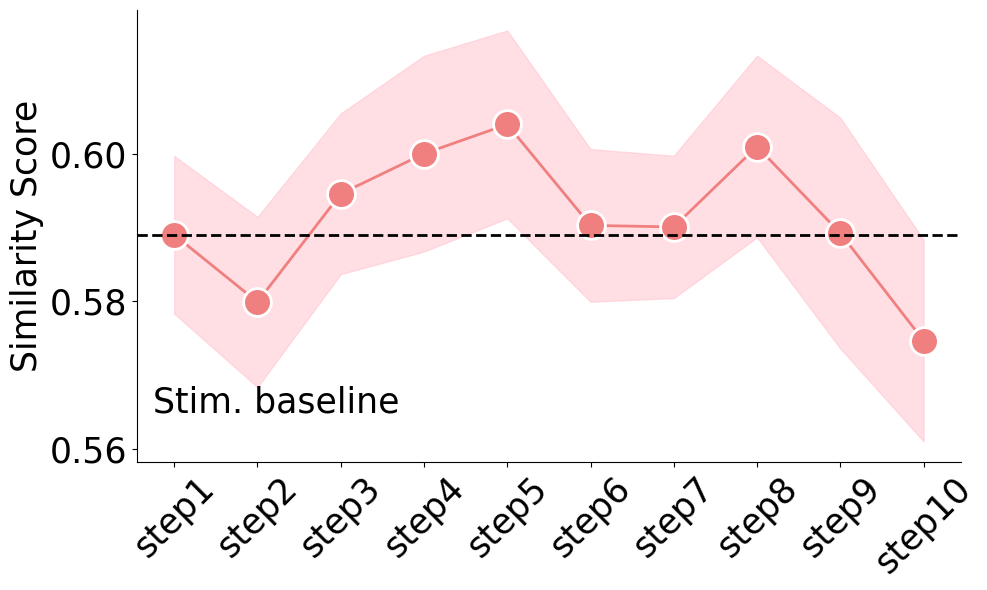

In [9]:
import numpy as np

# # 示例数据
# x = np.random.normal(0, 1, 100)
# y = x * 0.685 + np.random.normal(0, 0.5, 100)
rewards = np.array(final_array, dtype=np.float64)

plot_ratings(rewards, save_path=f"/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/line_plots_{feature_type}.png")